# **Import Libraries**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# **Load Dataset**

In [39]:
Credit_card_data = pd.read_csv("creditcard.csv")

Credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **Dataset Overview**

In [40]:
Credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [41]:
Credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


# **EDA**

In [42]:
Credit_card_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# **Class Distribution (Pie Chart)**

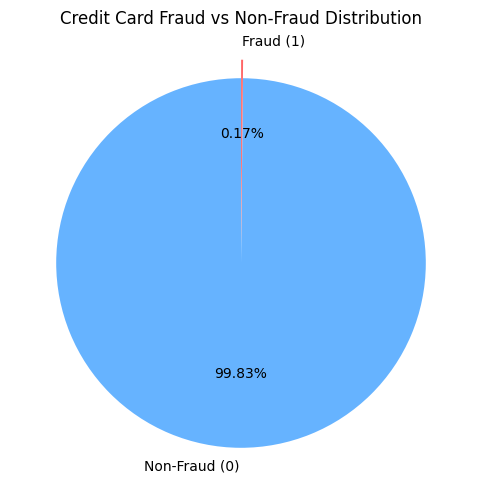

In [43]:
class_counts = Credit_card_data['Class'].value_counts()

plt.figure(figsize=(6,6))

colors = ['#66b3ff', '#ff6666']

plt.pie(
    class_counts,
    labels=['Non-Fraud (0)', 'Fraud (1)'],
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.1)
)

plt.title("Credit Card Fraud vs Non-Fraud Distribution")
plt.show()

# **Transaction Amount Distribution**

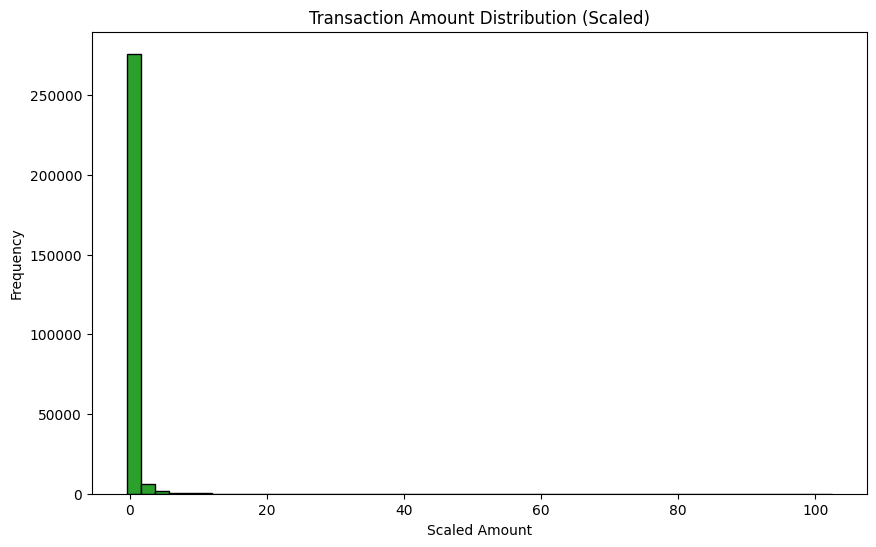

In [44]:
scaler = StandardScaler()
Credit_card_data_temp = Credit_card_data.copy()
Credit_card_data_temp['Amount_scaled'] = scaler.fit_transform(Credit_card_data_temp[['Amount']])

plt.figure(figsize=(10,6))

plt.hist(
    Credit_card_data_temp['Amount_scaled'],
    bins=50,
    color='#2ca02c',
    edgecolor='black'
)

plt.title("Transaction Amount Distribution (Scaled)")
plt.xlabel("Scaled Amount")
plt.ylabel("Frequency")

plt.show()

# **Correlation Heatmap**

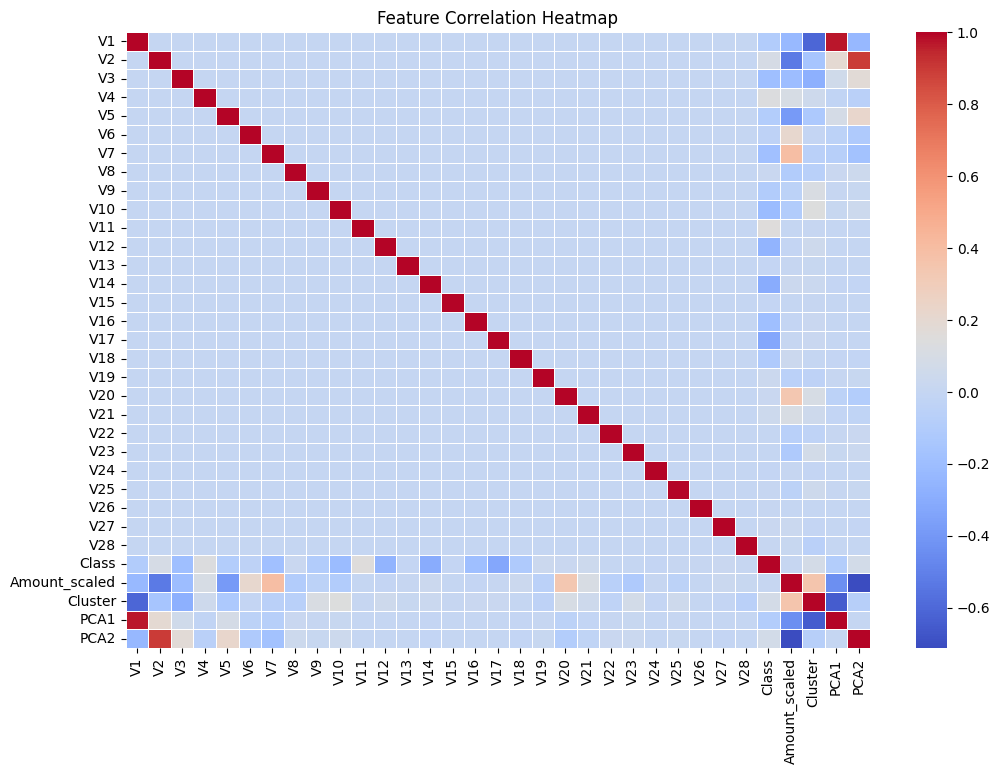

In [35]:
plt.figure(figsize=(12,8))

corr = Credit_card_data.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

# **Top Feature Variance**

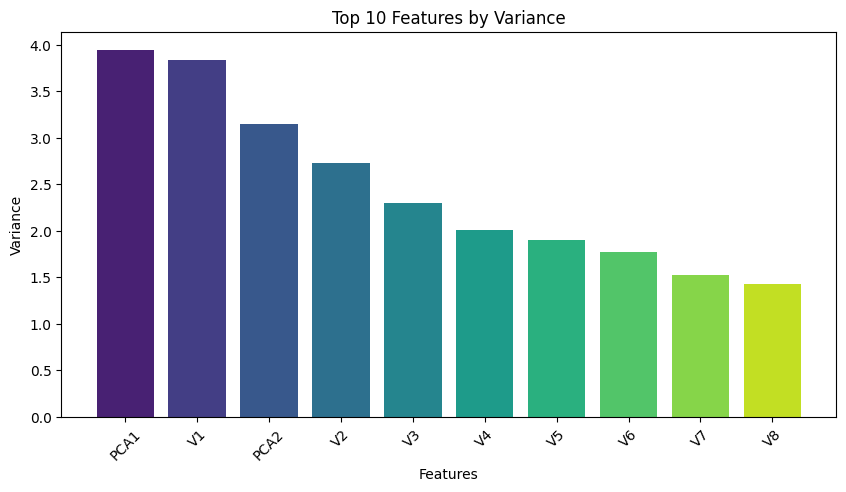

In [36]:
feature_variance = Credit_card_data.var().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

colors = sns.color_palette("viridis", len(feature_variance))

plt.bar(feature_variance.index, feature_variance.values, color=colors)

plt.xticks(rotation=45)
plt.title("Top 10 Features by Variance")
plt.xlabel("Features")
plt.ylabel("Variance")

plt.show()

# **Fraud vs Non-Fraud Amount Comparison**

/tmp/ipykernel_2857/3301844657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


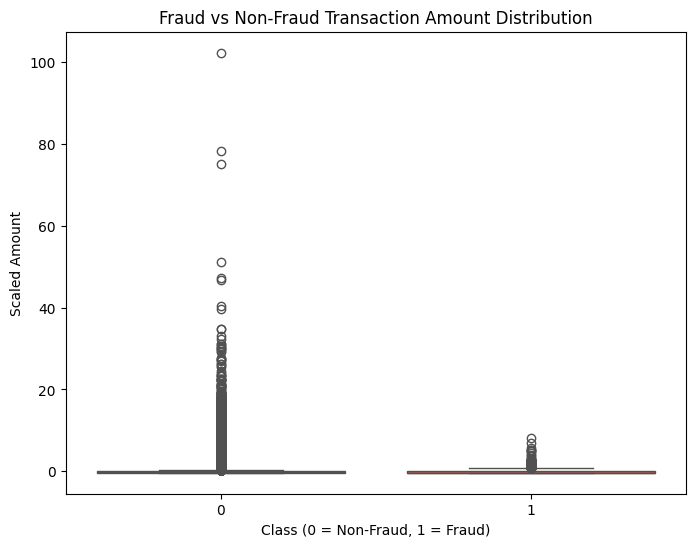

In [45]:
scaler = StandardScaler()
Credit_card_data['Amount_scaled'] = scaler.fit_transform(Credit_card_data[['Amount']])

plt.figure(figsize=(8,6))

sns.boxplot(
    x='Class',
    y='Amount_scaled',
    data=Credit_card_data,
    palette=['#3498db', '#e74c3c']
)

plt.title("Fraud vs Non-Fraud Transaction Amount Distribution")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Scaled Amount")

plt.show()

# **Class Distribution (Imbalance Check)**

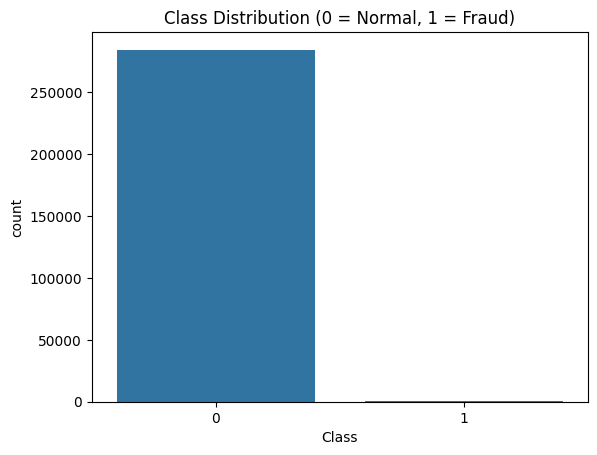

In [46]:
sns.countplot(x='Class', data=Credit_card_data)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

# **Feature Scaling**

In [12]:
scaler = StandardScaler()

Credit_card_data['Amount_scaled'] = scaler.fit_transform(Credit_card_data[['Amount']])

Credit_card_data.drop(['Amount', 'Time'], axis=1, inplace=True)

# **Define Features and Target**

In [13]:
X = Credit_card_data.drop('Class', axis=1)
y = Credit_card_data['Class']

# **Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **Logistic Regression Model**

In [15]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred_log = log_model.predict(X_test)

# **Random Forest Model**

In [17]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [18]:
y_pred_rf = rf_model.predict(X_test)

# **Model Evaluation – Logistic Regression**

In [19]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_log))

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9991573329588147
ROC AUC Score: 0.8213142636063991
[[56851    13]
 [   35    63]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



# **Confusion Matrix Visualization**

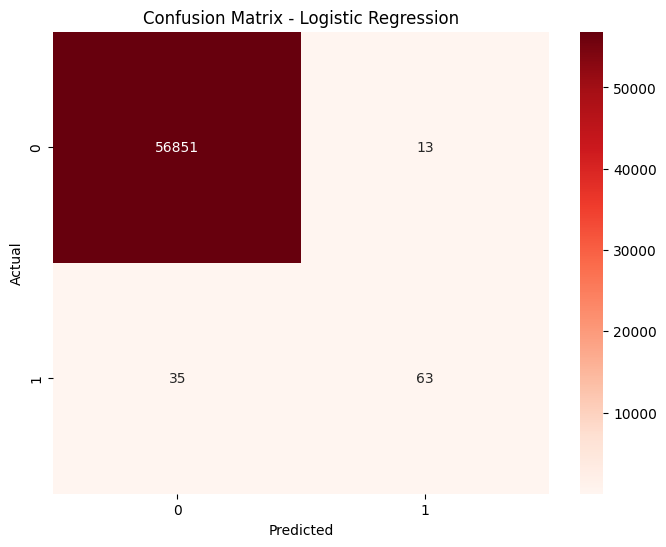

In [20]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8,6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Model Evaluation – Random Forest**

In [21]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9996137776061234
ROC AUC Score: 0.9132213415754596
[[56859     5]
 [   17    81]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



# **Confusion Matrix Visualization**

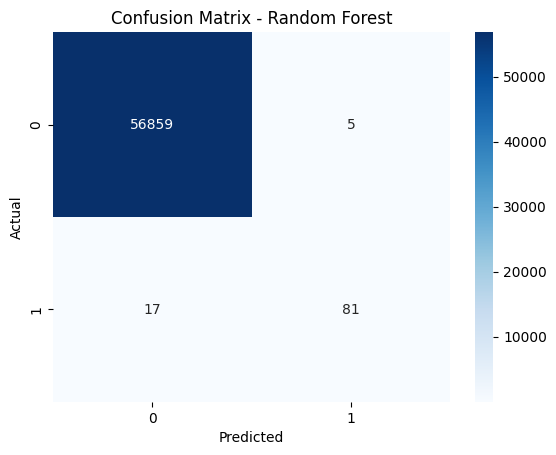

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Feature Importance (Random Forest)**

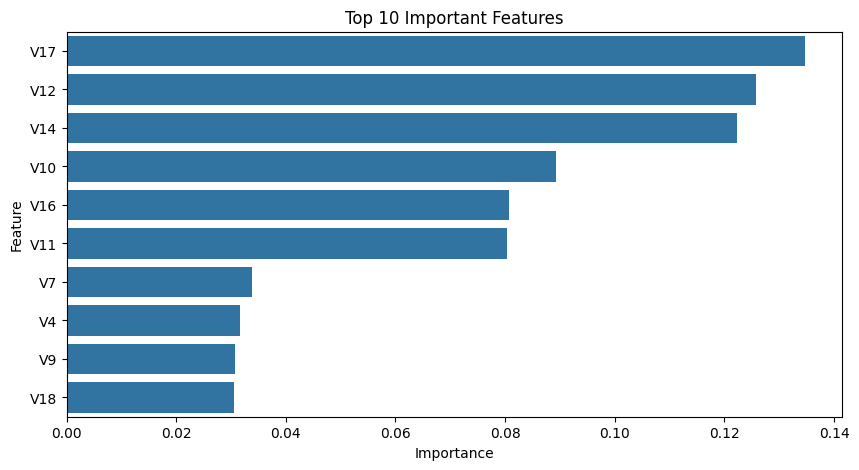

In [23]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features")
plt.show()

# **K-MEANS UNSUPERVISED LEARNING**

# **Prepare Data for Clustering**

In [24]:
X_cluster = Credit_card_data.drop('Class', axis=1)

# **Elbow Method (Optimal Clusters)**

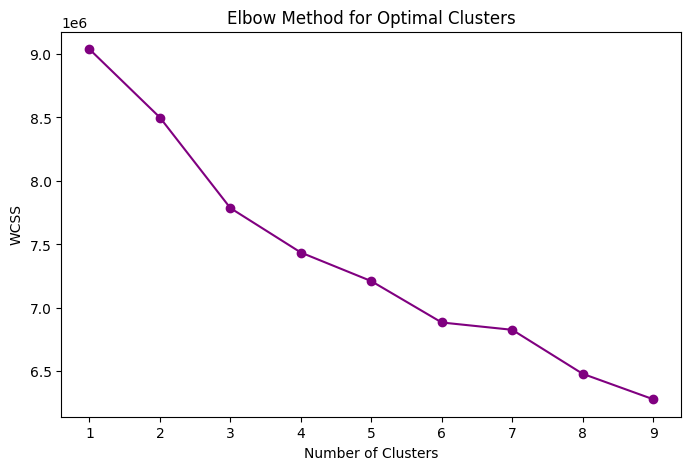

In [25]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 10), wcss, marker='o', color='purple')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# **Apply K-Means Clustering**

In [26]:
kmeans = KMeans(n_clusters=2, random_state=42)
Credit_card_data['Cluster'] = kmeans.fit_predict(X_cluster)

In [27]:
Credit_card_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Cluster
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,0


# **PCA for 2D Visualization**

In [28]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_cluster)

Credit_card_data['PCA1'] = pca_components[:, 0]
Credit_card_data['PCA2'] = pca_components[:, 1]

# **Cluster Visualization (Colored Plot with Labels)**

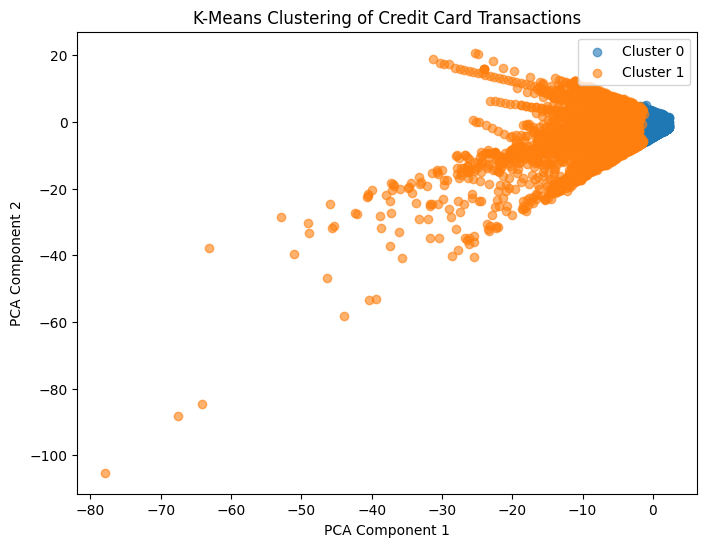

In [29]:
plt.figure(figsize=(8,6))

colors = ['#1f77b4', '#ff7f0e']

for i in range(2):
    clustered_data = Credit_card_data[Credit_card_data['Cluster'] == i]
    plt.scatter(
        clustered_data['PCA1'],
        clustered_data['PCA2'],
        label=f'Cluster {i}',
        color=colors[i],
        alpha=0.6
    )

plt.title("K-Means Clustering of Credit Card Transactions")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()